# TabTransformer + GBDT 앙상블 — Optuna HPO 버전

- **피처 엔지니어링**: Year 범주형, 교호작용 피처 (TabTransformer_FE 동일)
- **Optuna TPE + MedianPruner**: 하이퍼파라미터 자동 최적화
- **per-fold TT 재학습** + **GroupKFold(Race+Year) 5-fold OOF**
- 가중 최적화 Soft Voting 앙상블 + Ablation
- 결과 → `experiment_log_hpo.xlsx` (runs / hpo_trials / fold_timing / fold_auc)

In [1]:
import gc, copy, os, time
from contextlib import nullcontext
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP     = (device.type == 'cuda')
PIN         = (device.type == 'cuda')
NUM_WORKERS = 0
XGB_DEVICE  = 'cuda' if device.type == 'cuda' else 'cpu'
LOG_XLSX    = 'experiment_log_hpo.xlsx'

print('torch', torch.__version__, '| device', device, '| AMP', USE_AMP)
if device.type == 'cuda':
    print('GPU :', torch.cuda.get_device_name(0))

torch 2.12.0+cu132 | device cuda | AMP True
GPU : NVIDIA GeForce RTX 5060 Ti


c:\Users\PC\AppData\Local\pypoetry\Cache\virtualenvs\playground-series-s6e5-s57EiPDB-py3.14\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 실험 설정 & HPO 파라미터

In [2]:
# ── 최종 OOF 학습용 기본값 (HPO 완료 후 자동 덮어씀) ──────────────────────
EXPERIMENT_CONFIG = {
    'experiment_name' : 'hpo_fe_exp01',
    'n_layers'        : 4,
    'n_heads'         : 4,
    'dim_feedforward' : 512,
    'dropout'         : 0.10,
    'n_epochs'        : 80,
    'patience'        : 12,
    'batch_size'      : 4096,
    'lr'              : 2e-4,
    'weight_decay'    : 1e-4,
    'warmup_epochs'   : 5,
    'grad_clip'       : 1.0,
}

# ── HPO 설정 ──────────────────────────────────────────────────────────────────
RUN_HPO       = True   # False → EXPERIMENT_CONFIG 그대로 사용
HPO_N_TRIALS  = 20     # Optuna 시도 횟수
HPO_MAX_EPOCH = 25     # HPO 중 epoch 상한
HPO_PATIENCE  = 8      # HPO 중 early stopping patience
HPO_N_SPLITS  = 2      # HPO 중 fold 수
HPO_GROUP_FRAC = 0.5   # HPO용 그룹 서브샘플 비율 (속도↑)

print(f"실험: {EXPERIMENT_CONFIG['experiment_name']}")
print(f"HPO: {'ON' if RUN_HPO else 'OFF'} | {HPO_N_TRIALS} trials | {HPO_N_SPLITS}-fold | max {HPO_MAX_EPOCH}ep | {HPO_GROUP_FRAC*100:.0f}% 그룹 서브샘플")
for k, v in EXPERIMENT_CONFIG.items():
    if k != 'experiment_name':
        print(f"  {k:<18}: {v}")

실험: hpo_fe_exp01
HPO: ON | 20 trials | 2-fold | max 25ep | 50% 그룹 서브샘플
  n_layers          : 4
  n_heads           : 4
  dim_feedforward   : 512
  dropout           : 0.1
  n_epochs          : 80
  patience          : 12
  batch_size        : 4096
  lr                : 0.0002
  weight_decay      : 0.0001
  warmup_epochs     : 5
  grad_clip         : 1.0


## 1. 데이터 로딩 & 피처 엔지니어링

- Year → 범주형, 조합 피처(Driver×Compound, Driver×Race 등) 추가
- 연속형 파생 피처 5개 추가

In [3]:
data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test  = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')
print('Train', train.shape, '| Test', test.shape)

cat_features  = ['Driver', 'Compound', 'Race', 'Year',
                 'Driver_Compound', 'Driver_Race', 'Compound_Race', 'Driver_Compound_Race']
cont_features = ['LapNumber', 'Stint', 'TyreLife', 'Position',
                 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                 'RaceProgress', 'Position_Change', 'PitStop',
                 'TyreLife_x_LapNumber', 'RaceProgress_x_TyreLife',
                 'LapDelta_DIV_LapTime', 'CumDeg_DIV_TyreLife', 'LapNumber_DIV_TyreLife']
target = 'PitNextLap'
emb_dim_map = {
    'Driver': 32, 'Compound': 4, 'Race': 8, 'Year': 4,
    'Driver_Compound': 32, 'Driver_Race': 32,
    'Compound_Race'  :  8, 'Driver_Compound_Race': 32,
}

def add_features(df):
    df = df.copy()
    df['TyreLife_x_LapNumber']    = df['TyreLife'] * df['LapNumber']
    df['RaceProgress_x_TyreLife'] = df['RaceProgress'] * df['TyreLife']
    df['LapDelta_DIV_LapTime']    = df['LapTime_Delta'] / (df['LapTime (s)'] + 1e-6)
    df['CumDeg_DIV_TyreLife']     = df['Cumulative_Degradation'] / (df['TyreLife'] + 1e-6)
    df['LapNumber_DIV_TyreLife']  = df['LapNumber'] / (df['TyreLife'] + 1e-6)
    df['Driver_Compound']         = df['Driver'].astype(str) + '_' + df['Compound'].astype(str)
    df['Driver_Race']             = df['Driver'].astype(str) + '_' + df['Race'].astype(str)
    df['Compound_Race']           = df['Compound'].astype(str) + '_' + df['Race'].astype(str)
    df['Driver_Compound_Race']    = (df['Driver'].astype(str) + '_' +
                                     df['Compound'].astype(str) + '_' + df['Race'].astype(str))
    return df

all_data = pd.concat([train, test], ignore_index=True)
all_data = add_features(all_data)

cat_dims, cat_emb_dims = [], []
for col in cat_features:
    le = LabelEncoder()
    all_data[col + '_enc'] = le.fit_transform(all_data[col].astype(str))
    cat_dims.append(len(le.classes_))
    cat_emb_dims.append(emb_dim_map[col])

cat_enc_cols = [c + '_enc' for c in cat_features]
train_df = all_data.iloc[:len(train)].copy()
test_df  = all_data.iloc[len(train):].copy().reset_index(drop=True)

y      = train[target].values.astype(np.float32)
groups = (train['Race'].astype(str) + '_' + train['Year'].astype(str)).values
pos_rate = y.mean()
spw = (1 - pos_rate) / pos_rate
print('cat_dims', dict(zip(cat_features, cat_dims)))
print('pos rate', round(float(pos_rate), 4), '| scale_pos_weight', round(spw, 3))
print('groups (Race+Year):', len(np.unique(groups)))
print(f'cat: {len(cat_features)}개 | cont: {len(cont_features)}개')

Train (439140, 16) | Test (188165, 15)
cat_dims {'Driver': 887, 'Compound': 5, 'Race': 26, 'Year': 4, 'Driver_Compound': 3021, 'Driver_Race': 15408, 'Compound_Race': 100, 'Driver_Compound_Race': 35737}
pos rate 0.199 | scale_pos_weight 4.026
groups (Race+Year): 104
cat: 8개 | cont: 15개


## 2. TabTransformer & Dataset 정의

In [4]:
class TabTransformer(nn.Module):
    def __init__(self, cat_dims, cat_emb_dims, n_continuous,
                 n_heads=None, n_layers=None, dim_feedforward=None, dropout=None):
        cfg = EXPERIMENT_CONFIG
        n_heads         = n_heads         or cfg['n_heads']
        n_layers        = n_layers        or cfg['n_layers']
        dim_feedforward = dim_feedforward or cfg['dim_feedforward']
        dropout         = dropout if dropout is not None else cfg['dropout']
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, emb_dim) for n_cats, emb_dim in zip(cat_dims, cat_emb_dims)])
        self.emb_dim = max(cat_emb_dims)
        self.projections = nn.ModuleList([
            nn.Linear(d, self.emb_dim) if d != self.emb_dim else nn.Identity()
            for d in cat_emb_dims])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.emb_dim, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        total_dim = self.emb_dim * len(cat_dims) + n_continuous
        self.classifier = nn.Sequential(
            nn.LayerNorm(total_dim), nn.Dropout(dropout),
            nn.Linear(total_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64),  nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1))

    def get_embeddings(self, cat_x, cont_x):
        embs = [proj(emb(cat_x[:, i]))
                for i, (emb, proj) in enumerate(zip(self.embeddings, self.projections))]
        emb_seq = torch.stack(embs, dim=1)
        emb_seq = self.transformer(emb_seq)
        return torch.cat([emb_seq.flatten(1), cont_x], dim=1)

    def forward(self, cat_x, cont_x):
        return self.classifier(self.get_embeddings(cat_x, cont_x)).squeeze(-1)


class TabDataset(Dataset):
    def __init__(self, df, cat_cols, cont_cols, labels=None):
        self.cat  = torch.LongTensor(df[cat_cols].values)
        self.cont = torch.FloatTensor(df[cont_cols].values)
        self.labels = torch.FloatTensor(labels) if labels is not None else None
    def __len__(self):
        return len(self.cat)
    def __getitem__(self, i):
        if self.labels is not None:
            return self.cat[i], self.cont[i], self.labels[i]
        return self.cat[i], self.cont[i]

EMB_OUT = max(cat_emb_dims) * len(cat_dims) + len(cont_features)
print('임베딩 출력 차원:', EMB_OUT)

임베딩 출력 차원: 271


## 3. 학습/추출 유틸 (AMP + cfg_override + Optuna pruning)

`train_tabtransformer`의 `cfg_override`로 EXPERIMENT_CONFIG 일부를 임시 덮어쓸 수 있다.
`trial`이 주어지면 epoch마다 AUC를 보고하고 MedianPruner 판단에 따라 조기 종료한다.

In [5]:
def amp_ctx():
    return torch.autocast(device_type='cuda', enabled=True) if USE_AMP else nullcontext()

def _loader(df, cat_cols, cont_cols, labels=None, bs=4096, shuffle=False):
    return DataLoader(TabDataset(df, cat_cols, cont_cols, labels),
                      batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN)

def predict_tt(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats  = cats.to(device, non_blocking=True)
            conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                logit = model(cats, conts)
            out.append(torch.sigmoid(logit.float()).cpu().numpy())
    return np.concatenate(out)

def extract_embeddings(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats  = cats.to(device, non_blocking=True)
            conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                e = model.get_embeddings(cats, conts)
            out.append(e.float().cpu().numpy())
    return np.vstack(out)

def train_tabtransformer(tr_df, va_df, y_tr, y_va, cat_cols, cont_cols,
                          verbose=False, cfg_override=None, trial=None):
    cfg = {**EXPERIMENT_CONFIG, **(cfg_override or {})}
    n_epochs   = cfg['n_epochs']
    patience   = cfg['patience']
    batch_size = cfg['batch_size']
    lr         = cfg['lr']
    warmup_ep  = cfg['warmup_epochs']
    grad_clip  = cfg['grad_clip']

    model = TabTransformer(
        cat_dims, cat_emb_dims, len(cont_cols),
        n_layers=cfg['n_layers'], n_heads=cfg['n_heads'],
        dim_feedforward=cfg['dim_feedforward'], dropout=cfg['dropout']
    ).to(device)
    pw = torch.tensor([(1 - y_tr.mean()) / y_tr.mean()], dtype=torch.float32, device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg['weight_decay'])
    warmup_sch = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1,
                                             end_factor=1.0, total_iters=warmup_ep)
    cosine_sch = optim.lr_scheduler.CosineAnnealingLR(
                     optimizer, T_max=max(n_epochs - warmup_ep, 1))
    scheduler  = optim.lr_scheduler.SequentialLR(
                     optimizer, schedulers=[warmup_sch, cosine_sch], milestones=[warmup_ep])
    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    tr_loader  = _loader(tr_df, cat_cols, cont_cols, y_tr, bs=batch_size, shuffle=True)

    best_auc, best_state, no_improve, epochs_done = 0.0, None, 0, 0
    for epoch in range(n_epochs):
        epochs_done = epoch + 1
        model.train()
        for cats, conts, labels in tr_loader:
            cats   = cats.to(device, non_blocking=True)
            conts  = conts.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with amp_ctx():
                loss = criterion(model(cats, conts), labels)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            scaler_amp.step(optimizer)
            scaler_amp.update()
        scheduler.step()
        auc = roc_auc_score(y_va, predict_tt(model, va_df, cat_cols, cont_cols))
        if verbose:
            print(f'    epoch {epoch+1:02d} | val AUC {auc:.4f}')
        if trial is not None:
            trial.report(auc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if auc > best_auc:
            best_auc, best_state, no_improve = auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_auc, epochs_done

## 4. Optuna HPO (선택 실행)

- **TPE 샘플러**: 이전 trial 결과를 반영한 베이즈 최적화
- **MedianPruner**: epoch 단위 pruning — 중앙값보다 낮은 trial 조기 종료
- **속도 전략**: `HPO_GROUP_FRAC` 비율의 Race+Year 그룹 서브샘플 + 2-fold + max 25ep

`RUN_HPO = False`로 두면 EXPERIMENT_CONFIG 초기값 그대로 OOF 학습으로 진행.

In [6]:
hpo_elapsed    = 0.0
hpo_trials_df  = pd.DataFrame()
hpo_best_value = None

if RUN_HPO:
    # ── 서브샘플 그룹 선택 ─────────────────────────────────────────────────
    unique_grp = np.unique(groups)
    rng_hpo    = np.random.default_rng(SEED)
    hpo_grps   = rng_hpo.choice(unique_grp,
                                 size=max(HPO_N_SPLITS, int(len(unique_grp) * HPO_GROUP_FRAC)),
                                 replace=False)
    hpo_mask   = np.isin(groups, hpo_grps)
    hpo_df     = train_df[hpo_mask].copy()
    hpo_y      = y[hpo_mask]
    hpo_groups = groups[hpo_mask]
    print(f'HPO 서브샘플: {hpo_mask.sum():,}행 / {len(hpo_grps)} 그룹')

    # ── Optuna objective ──────────────────────────────────────────────────
    def hpo_objective(trial):
        cfg_t = {
            'n_layers'       : trial.suggest_int('n_layers', 2, 6),
            'n_heads'        : trial.suggest_categorical('n_heads', [2, 4, 8]),
            'dim_feedforward': trial.suggest_categorical('dim_feedforward', [256, 512, 1024]),
            'dropout'        : trial.suggest_float('dropout', 0.05, 0.30),
            'n_epochs'       : HPO_MAX_EPOCH,
            'patience'       : HPO_PATIENCE,
            'batch_size'     : trial.suggest_categorical('batch_size', [2048, 4096, 8192]),
            'lr'             : trial.suggest_float('lr', 5e-5, 5e-4, log=True),
            'weight_decay'   : trial.suggest_float('weight_decay', 1e-5, 5e-4, log=True),
            'warmup_epochs'  : trial.suggest_int('warmup_epochs', 3, 8),
            'grad_clip'      : EXPERIMENT_CONFIG['grad_clip'],
        }
        gkf_h = GroupKFold(n_splits=HPO_N_SPLITS)
        aucs  = []
        for tr, va in gkf_h.split(hpo_df, hpo_y, groups=hpo_groups):
            sc    = StandardScaler().fit(hpo_df.iloc[tr][cont_features])
            tr_h  = hpo_df.iloc[tr].copy();  tr_h[cont_features] = sc.transform(tr_h[cont_features])
            va_h  = hpo_df.iloc[va].copy();  va_h[cont_features] = sc.transform(va_h[cont_features])
            model = None
            try:
                model, auc, _ = train_tabtransformer(
                    tr_h, va_h, hpo_y[tr], hpo_y[va],
                    cat_enc_cols, cont_features,
                    cfg_override=cfg_t, trial=trial)
                aucs.append(auc)
            except optuna.TrialPruned:
                raise
            finally:
                del model
                gc.collect()
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
        return float(np.mean(aucs))

    # ── 최적화 실행 ────────────────────────────────────────────────────────
    t_hpo = time.time()
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
    study.optimize(hpo_objective, n_trials=HPO_N_TRIALS, show_progress_bar=True)
    hpo_elapsed    = time.time() - t_hpo
    hpo_best_value = study.best_value
    hpo_trials_df  = study.trials_dataframe()

    n_done   = sum(1 for t in study.trials if t.state.name == 'COMPLETE')
    n_pruned = sum(1 for t in study.trials if t.state.name == 'PRUNED')
    print(f'HPO 완료: {hpo_elapsed:.0f}s | 완료 {n_done} / 가지치기 {n_pruned} / 총 {len(study.trials)} trials')
    print(f'Best trial #{study.best_trial.number} | AUC {study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k:<18}: {v}')

    # ── EXPERIMENT_CONFIG 업데이트 ─────────────────────────────────────────
    HPO_KEYS = ('n_layers', 'n_heads', 'dim_feedforward', 'dropout',
                 'batch_size', 'lr', 'weight_decay', 'warmup_epochs')
    EXPERIMENT_CONFIG.update({k: v for k, v in study.best_params.items() if k in HPO_KEYS})
    EXPERIMENT_CONFIG['experiment_name'] += '_optuna'
    print('\n[업데이트된 EXPERIMENT_CONFIG]')
    for k, v in EXPERIMENT_CONFIG.items():
        if k != 'experiment_name':
            print(f'  {k:<18}: {v}')

else:
    print('HPO 건너뜀 — EXPERIMENT_CONFIG 현재값 사용')
    for k, v in EXPERIMENT_CONFIG.items():
        if k != 'experiment_name':
            print(f'  {k:<18}: {v}')

HPO 서브샘플: 212,783행 / 52 그룹


Best trial: 13. Best value: 0.88692: 100%|██████████| 20/20 [12:49<00:00, 38.46s/it]

HPO 완료: 769s | 완료 7 / 가지치기 13 / 총 20 trials
Best trial #13 | AUC 0.8869
  n_layers          : 3
  n_heads           : 2
  dim_feedforward   : 256
  dropout           : 0.2990041329368588
  batch_size        : 2048
  lr                : 0.0003805403709746153
  weight_decay      : 0.00013336340628557347
  warmup_epochs     : 6

[업데이트된 EXPERIMENT_CONFIG]
  n_layers          : 3
  n_heads           : 2
  dim_feedforward   : 256
  dropout           : 0.2990041329368588
  n_epochs          : 80
  patience          : 12
  batch_size        : 2048
  lr                : 0.0003805403709746153
  weight_decay      : 0.00013336340628557347
  warmup_epochs     : 6
  grad_clip         : 1.0


## 5. per-fold OOF 루프

fold마다: ① per-fold 스케일링 → ② TT 재학습 → ③ TT OOF/test →
④ 임베딩 추출 → ⑤ LightGBM/XGBoost 학습. 각 구간 시간 및 GPU 피크 메모리 기록.

In [7]:
gkf    = GroupKFold(n_splits=5)
splits = list(gkf.split(train_df, y, groups=groups))

oof_tt  = np.zeros(len(train_df))
oof_lgb = np.zeros(len(train_df))
oof_xgb = np.zeros(len(train_df))
tt_test_folds, lgb_test_folds, xgb_test_folds = [], [], []
fold_log   = []
fold_times = []

lgb_params = {'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.05,
              'num_leaves': 127, 'max_depth': -1, 'min_child_samples': 50,
              'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
              'scale_pos_weight': spw, 'n_jobs': -1, 'verbose': -1, 'random_state': SEED}
xgb_params = {'objective': 'binary:logistic', 'eval_metric': 'auc', 'learning_rate': 0.05,
              'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'scale_pos_weight': spw, 'tree_method': 'hist', 'device': XGB_DEVICE,
              'random_state': SEED, 'verbosity': 0}

t0 = time.time()
for f, (tr, va) in enumerate(splits):
    print(f'===== Fold {f} =====')
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()

    sc    = StandardScaler().fit(train_df.iloc[tr][cont_features])
    tr_df = train_df.iloc[tr].copy(); tr_df[cont_features] = sc.transform(tr_df[cont_features])
    va_df = train_df.iloc[va].copy(); va_df[cont_features] = sc.transform(va_df[cont_features])
    te_df = test_df.copy();           te_df[cont_features] = sc.transform(te_df[cont_features])

    t_tt  = time.time()
    model, tt_auc, ep_done = train_tabtransformer(
        tr_df, va_df, y[tr], y[va], cat_enc_cols, cont_features)
    tt_time = time.time() - t_tt
    torch.save(model.state_dict(), f'best_tabtransformer_fold{f}.pth')
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0.0

    oof_tt[va] = predict_tt(model, va_df, cat_enc_cols, cont_features)
    tt_test_folds.append(predict_tt(model, te_df, cat_enc_cols, cont_features))

    emb_tr = extract_embeddings(model, tr_df, cat_enc_cols, cont_features)
    emb_va = extract_embeddings(model, va_df, cat_enc_cols, cont_features)
    emb_te = extract_embeddings(model, te_df, cat_enc_cols, cont_features)

    t_lgb = time.time()
    dtr   = lgb.Dataset(emb_tr, label=y[tr]); dva = lgb.Dataset(emb_va, label=y[va])
    lgbm  = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[va] = lgbm.predict(emb_va)
    lgb_test_folds.append(lgbm.predict(emb_te))
    lgb_auc  = roc_auc_score(y[va], oof_lgb[va])
    lgb_time = time.time() - t_lgb

    t_xgb = time.time()
    dxt   = xgb.DMatrix(emb_tr, label=y[tr]); dxv = xgb.DMatrix(emb_va, label=y[va])
    xgbm  = xgb.train(xgb_params, dxt, num_boost_round=1000, evals=[(dxv, 'val')],
                      early_stopping_rounds=50, verbose_eval=False)
    oof_xgb[va] = xgbm.predict(dxv)
    xgb_test_folds.append(xgbm.predict(xgb.DMatrix(emb_te)))
    xgb_auc  = roc_auc_score(y[va], oof_xgb[va])
    xgb_time = time.time() - t_xgb

    print(f'  AUC : TT {tt_auc:.4f} | LGBM {lgb_auc:.4f} | XGB {xgb_auc:.4f}')
    print(f'  시간: TT {tt_time:.0f}s ({ep_done}ep) | LGBM {lgb_time:.0f}s | XGB {xgb_time:.0f}s'
          + (f' | GPU peak {peak_mem_mb:.0f}MB' if device.type == 'cuda' else ''))
    fold_log.append({'fold': f, 'tt': tt_auc, 'lgb': lgb_auc, 'xgb': xgb_auc})
    fold_times.append({'fold': f,
                       'tt_s': round(tt_time, 1), 'lgb_s': round(lgb_time, 1),
                       'xgb_s': round(xgb_time, 1), 'ep': ep_done,
                       'gpu_peak_mb': round(peak_mem_mb, 0)})
    del model, emb_tr, emb_va, emb_te
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

total_elapsed = time.time() - t0
ft = pd.DataFrame(fold_times)
print(f'\nOOF AUC  TT {roc_auc_score(y, oof_tt):.4f} | LGBM {roc_auc_score(y, oof_lgb):.4f} | XGB {roc_auc_score(y, oof_xgb):.4f}')
print(f'총 학습 시간: {total_elapsed:.0f}s ({total_elapsed/60:.1f}분)')
print(f'  TT 합계 {ft.tt_s.sum():.0f}s | LGBM {ft.lgb_s.sum():.0f}s | XGB {ft.xgb_s.sum():.0f}s')
print(ft[['fold', 'tt_s', 'lgb_s', 'xgb_s', 'ep', 'gpu_peak_mb']].to_string(index=False))

===== Fold 0 =====
  AUC : TT 0.8902 | LGBM 0.9221 | XGB 0.9208
  시간: TT 128s (34ep) | LGBM 17s | XGB 6s | GPU peak 282MB
===== Fold 1 =====
  AUC : TT 0.9111 | LGBM 0.9297 | XGB 0.9279
  시간: TT 95s (26ep) | LGBM 26s | XGB 8s | GPU peak 250MB
===== Fold 2 =====
  AUC : TT 0.9163 | LGBM 0.9383 | XGB 0.9371
  시간: TT 99s (26ep) | LGBM 17s | XGB 3s | GPU peak 250MB
===== Fold 3 =====
  AUC : TT 0.9031 | LGBM 0.9299 | XGB 0.9292
  시간: TT 97s (24ep) | LGBM 15s | XGB 3s | GPU peak 250MB
===== Fold 4 =====
  AUC : TT 0.8584 | LGBM 0.9057 | XGB 0.9010
  시간: TT 130s (33ep) | LGBM 11s | XGB 2s | GPU peak 250MB

OOF AUC  TT 0.8965 | LGBM 0.9261 | XGB 0.9243
총 학습 시간: 689s (11.5분)
  TT 합계 550s | LGBM 86s | XGB 22s
 fold  tt_s  lgb_s  xgb_s  ep  gpu_peak_mb
    0 128.4   17.0    5.7  34        282.0
    1  94.9   26.0    7.8  26        250.0
    2  98.8   17.2    3.0  26        250.0
    3  97.4   15.3    3.5  24        250.0
    4 130.3   11.0    2.4  33        250.0


## 6. 앙상블 — 등가중 vs 가중 최적화

In [8]:
auc_tt  = roc_auc_score(y, oof_tt)
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)

oof_df = pd.DataFrame({'tt': oof_tt, 'lgb': oof_lgb, 'xgb': oof_xgb})
print('OOF correlation:\n', oof_df.corr().round(4))

ens_equal = (oof_tt + oof_lgb + oof_xgb) / 3
auc_equal = roc_auc_score(y, ens_equal)
auc_gbdt  = roc_auc_score(y, (oof_lgb + oof_xgb) / 2)

best_w, best_auc_w = None, -1
for w1 in np.arange(0, 1.0001, 0.05):
    for w2 in np.arange(0, 1.0001 - w1, 0.05):
        w3 = 1 - w1 - w2
        a  = roc_auc_score(y, w1 * oof_tt + w2 * oof_lgb + w3 * oof_xgb)
        if a > best_auc_w:
            best_auc_w, best_w = a, (round(w1, 2), round(w2, 2), round(w3, 2))

oof_best = best_w[0] * oof_tt + best_w[1] * oof_lgb + best_w[2] * oof_xgb
gain = best_auc_w - max(auc_tt, auc_lgb, auc_xgb)
print(f'\n등가중 AUC {auc_equal:.4f} | GBDT앙상블 {auc_gbdt:.4f}')
print(f'가중최적 AUC {best_auc_w:.4f} | weights (tt,lgb,xgb)={best_w}')
print(f'앙상블 gain (vs 최고 단일) {gain:+.4f}')

OOF correlation:
          tt     lgb     xgb
tt   1.0000  0.9239  0.9305
lgb  0.9239  1.0000  0.9916
xgb  0.9305  0.9916  1.0000

등가중 AUC 0.9223 | GBDT앙상블 0.9259
가중최적 AUC 0.9262 | weights (tt,lgb,xgb)=(np.float64(0.0), np.float64(0.8), np.float64(0.2))
앙상블 gain (vs 최고 단일) +0.0001


## 7. 실험 로그 → Excel 저장

In [9]:
from datetime import datetime

_ft = pd.DataFrame(fold_times) if fold_times else pd.DataFrame()
_summary_row = {
    'timestamp'       : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'experiment_name' : EXPERIMENT_CONFIG['experiment_name'],
    'n_layers'        : EXPERIMENT_CONFIG['n_layers'],
    'n_heads'         : EXPERIMENT_CONFIG['n_heads'],
    'dim_feedforward' : EXPERIMENT_CONFIG['dim_feedforward'],
    'dropout'         : EXPERIMENT_CONFIG['dropout'],
    'n_epochs'        : EXPERIMENT_CONFIG['n_epochs'],
    'patience'        : EXPERIMENT_CONFIG['patience'],
    'lr'              : EXPERIMENT_CONFIG['lr'],
    'weight_decay'    : EXPERIMENT_CONFIG['weight_decay'],
    'warmup_epochs'   : EXPERIMENT_CONFIG['warmup_epochs'],
    'batch_size'      : EXPERIMENT_CONFIG['batch_size'],
    'oof_tt'          : round(float(auc_tt),      4),
    'oof_lgb'         : round(float(auc_lgb),     4),
    'oof_xgb'         : round(float(auc_xgb),     4),
    'oof_ensemble'    : round(float(best_auc_w),  4),
    'ensemble_gain'   : round(float(gain),        4),
    'best_w_tt'       : float(best_w[0]),
    'best_w_lgb'      : float(best_w[1]),
    'best_w_xgb'      : float(best_w[2]),
    'emb_gain'        : round(float(auc_lgb - auc_raw), 4) if 'auc_raw' in vars() else None,
    'total_elapsed_s' : round(total_elapsed, 1),
    'tt_total_s'      : round(float(_ft['tt_s'].sum()),  1) if not _ft.empty else None,
    'lgb_total_s'     : round(float(_ft['lgb_s'].sum()), 1) if not _ft.empty else None,
    'xgb_total_s'     : round(float(_ft['xgb_s'].sum()), 1) if not _ft.empty else None,
    'avg_ep'          : round(float(_ft['ep'].mean()),   1) if not _ft.empty else None,
    'gpu_peak_mb'     : round(float(_ft['gpu_peak_mb'].max()), 0) if not _ft.empty else None,
    'hpo_elapsed_s'   : round(hpo_elapsed, 1),
    'hpo_best_value'  : round(hpo_best_value, 4) if hpo_best_value is not None else None,
    'hpo_n_trials'    : len(hpo_trials_df) if not hpo_trials_df.empty else 0,
}

# runs 시트: 기존 파일 있으면 누적, 없으면 신규 생성
_runs_df = pd.DataFrame([_summary_row])
if os.path.exists(LOG_XLSX):
    with pd.ExcelFile(LOG_XLSX, engine='openpyxl') as _xf:
        if 'runs' in _xf.sheet_names:
            _existing = pd.read_excel(_xf, sheet_name='runs')
            _existing = _existing[_existing['experiment_name'] != EXPERIMENT_CONFIG['experiment_name']]
            _runs_df  = pd.concat([_existing, _runs_df], ignore_index=True)

with pd.ExcelWriter(LOG_XLSX, engine='openpyxl', mode='w') as _w:
    _runs_df.to_excel(_w, sheet_name='runs', index=False)
    pd.DataFrame(fold_log).to_excel(_w, sheet_name='fold_auc', index=False)
    if not _ft.empty:
        _ft.to_excel(_w, sheet_name='fold_timing', index=False)
    if not hpo_trials_df.empty:
        hpo_trials_df.to_excel(_w, sheet_name='hpo_trials', index=False)

print(f'Excel 저장 → {LOG_XLSX}')
print(_runs_df[['experiment_name', 'n_layers', 'dim_feedforward', 'lr',
                'oof_tt', 'oof_lgb', 'oof_ensemble', 'total_elapsed_s',
                'hpo_elapsed_s', 'hpo_best_value']].to_string(index=False))

Excel 저장 → experiment_log_hpo.xlsx
    experiment_name  n_layers  dim_feedforward       lr  oof_tt  oof_lgb  oof_ensemble  total_elapsed_s  hpo_elapsed_s  hpo_best_value
hpo_fe_exp01_optuna         3              256 0.000381  0.8965   0.9261        0.9262            688.8          769.2          0.8869


## 8. Ablation — raw 피처 vs TT 임베딩

In [10]:
raw_cols    = cont_features + cat_enc_cols
X_raw       = train_df[raw_cols].values
oof_lgb_raw = np.zeros(len(train_df))
for tr, va in splits:
    dtr = lgb.Dataset(X_raw[tr], label=y[tr]); dva = lgb.Dataset(X_raw[va], label=y[va])
    m   = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                    callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb_raw[va] = m.predict(X_raw[va])

auc_raw = roc_auc_score(y, oof_lgb_raw)
print(f'raw 피처 + LGBM      OOF AUC : {auc_raw:.4f}')
print(f'TT 임베딩 + LGBM     OOF AUC : {auc_lgb:.4f}')
print(f'임베딩 효용 (차이)           : {auc_lgb - auc_raw:+.4f}')

# Excel 로그에 emb_gain 업데이트
if os.path.exists(LOG_XLSX):
    with pd.ExcelFile(LOG_XLSX, engine='openpyxl') as _xf:
        _runs_df = pd.read_excel(_xf, sheet_name='runs')
        _rest    = {s: pd.read_excel(_xf, sheet_name=s)
                    for s in _xf.sheet_names if s != 'runs'}
    _runs_df.loc[_runs_df['experiment_name'] == EXPERIMENT_CONFIG['experiment_name'],
                 'emb_gain'] = round(float(auc_lgb - auc_raw), 4)
    with pd.ExcelWriter(LOG_XLSX, engine='openpyxl', mode='w') as _w:
        _runs_df.to_excel(_w, sheet_name='runs', index=False)
        for sname, sdf in _rest.items():
            sdf.to_excel(_w, sheet_name=sname, index=False)
    print(f'emb_gain 업데이트 → {LOG_XLSX}')

raw 피처 + LGBM      OOF AUC : 0.9320
TT 임베딩 + LGBM     OOF AUC : 0.9261
임베딩 효용 (차이)           : -0.0059
emb_gain 업데이트 → experiment_log_hpo.xlsx


## 9. 결과 시각화

               모델  OOF_AUC       F1
TabTransformer 단독 0.896489 0.647355
   LightGBM (임베딩) 0.926058 0.705217
    XGBoost (임베딩) 0.924311 0.701102
         GBDT 앙상블 0.925894 0.704270
     전체 앙상블 (등가중) 0.922324 0.692626
    전체 앙상블 (가중최적) 0.926165 0.705180

raw+LGBM 0.9320 | 임베딩 효용 -0.0059 | 가중 (np.float64(0.0), np.float64(0.8), np.float64(0.2)) | gain +0.0001


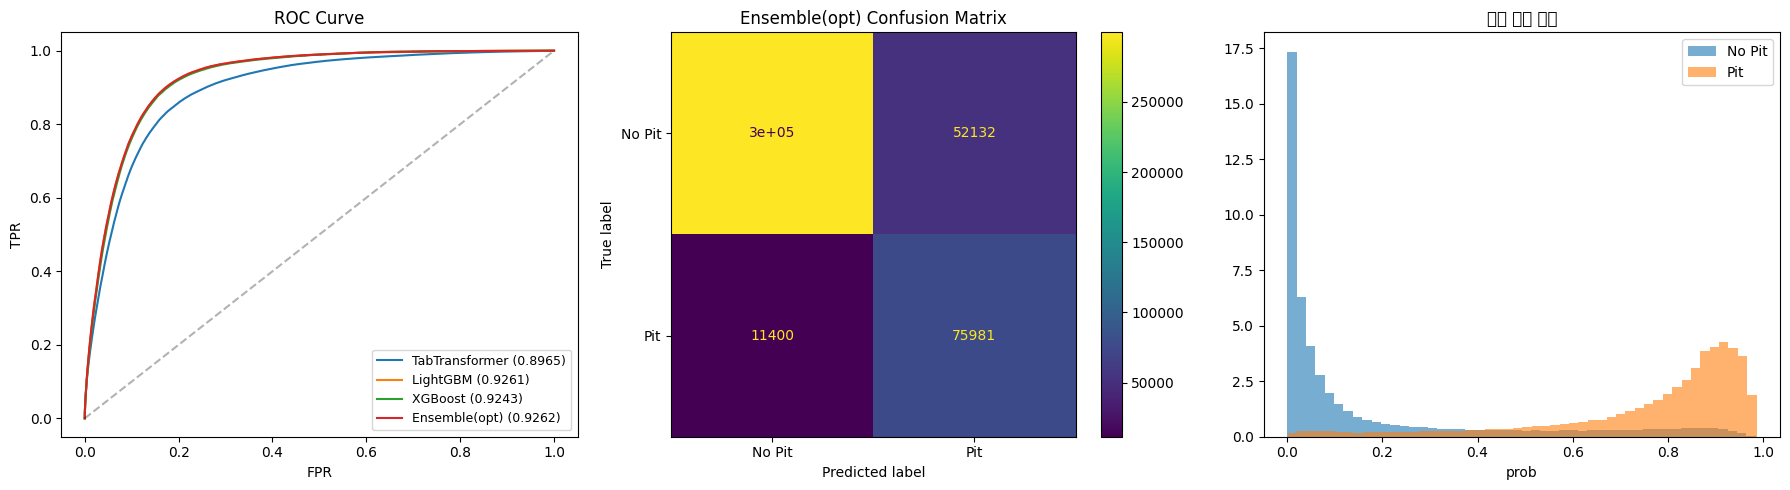

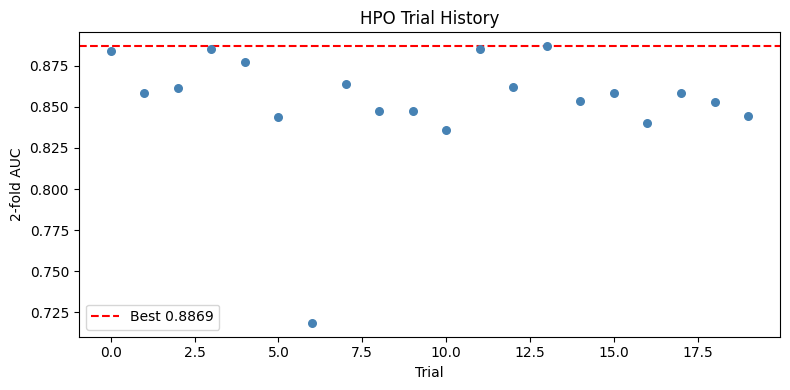

In [11]:
def f1_at(p):
    return f1_score(y, (p > 0.5).astype(int))

rows = [
    ('TabTransformer 단독',   auc_tt,     f1_at(oof_tt)),
    ('LightGBM (임베딩)',      auc_lgb,    f1_at(oof_lgb)),
    ('XGBoost (임베딩)',       auc_xgb,    f1_at(oof_xgb)),
    ('GBDT 앙상블',            auc_gbdt,   f1_at((oof_lgb + oof_xgb) / 2)),
    ('전체 앙상블 (등가중)',    auc_equal,  f1_at(ens_equal)),
    ('전체 앙상블 (가중최적)',  best_auc_w, f1_at(oof_best)),
]
res = pd.DataFrame(rows, columns=['모델', 'OOF_AUC', 'F1'])
print(res.to_string(index=False))
print(f'\nraw+LGBM {auc_raw:.4f} | 임베딩 효용 {auc_lgb-auc_raw:+.4f} | 가중 {best_w} | gain {gain:+.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, p in [('TabTransformer', oof_tt), ('LightGBM', oof_lgb),
                ('XGBoost', oof_xgb), ('Ensemble(opt)', oof_best)]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y, p):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=9)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

ConfusionMatrixDisplay.from_predictions(
    y, (oof_best > 0.5).astype(int), display_labels=['No Pit', 'Pit'], ax=axes[1])
axes[1].set_title('Ensemble(opt) Confusion Matrix')

axes[2].hist(oof_best[y == 0], bins=50, alpha=0.6, label='No Pit', density=True)
axes[2].hist(oof_best[y == 1], bins=50, alpha=0.6, label='Pit',    density=True)
axes[2].set_title('예측 확률 분포'); axes[2].set_xlabel('prob'); axes[2].legend()
plt.tight_layout(); plt.show()

if RUN_HPO and not hpo_trials_df.empty:
    val_col = [c for c in hpo_trials_df.columns if 'value' in c.lower()][0]
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    completed = hpo_trials_df.dropna(subset=[val_col])
    ax2.scatter(completed.index, completed[val_col], c='steelblue', s=30, zorder=3)
    ax2.axhline(study.best_value, color='red', linestyle='--', label=f'Best {study.best_value:.4f}')
    ax2.set_xlabel('Trial'); ax2.set_ylabel('2-fold AUC'); ax2.set_title('HPO Trial History')
    ax2.legend(); plt.tight_layout(); plt.show()

## 10. Test 추론 & 제출

In [12]:
tt_test  = np.mean(tt_test_folds,  axis=0)
lgb_test = np.mean(lgb_test_folds, axis=0)
xgb_test = np.mean(xgb_test_folds, axis=0)

final = best_w[0] * tt_test + best_w[1] * lgb_test + best_w[2] * xgb_test
submission['PitNextLap'] = final
out_csv = f'submission_{EXPERIMENT_CONFIG["experiment_name"]}.csv'
submission.to_csv(out_csv, index=False)
print(f'saved {out_csv}', submission.shape)
print(submission['PitNextLap'].describe())

saved submission_hpo_fe_exp01_optuna.csv (188165, 2)
count    188165.000000
mean          0.293553
std           0.350028
min           0.005080
25%           0.014882
50%           0.075263
75%           0.642775
max           0.974433
Name: PitNextLap, dtype: float64
